In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv(r"C:\Users\DELL-PC\Desktop\PGDM\Projects\customer_segmentation.csv")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0


In [9]:
print(df.columns)
print("---------------------------------")
print(df.isnull().sum())
print("---------------------------------")
print(df.info())

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')
---------------------------------
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumC

In [10]:
df = df.dropna()

In [13]:
#Convert date column into 3 columns date, month and year

parts = df['Dt_Customer'].str.split('-',n=3, expand=True)
df['day'] = parts[0].astype('int')
df['month'] = parts[1].astype('int')
df['year'] = parts[2].astype('int')

In [14]:
df.drop(['Z_CostContact','Z_Revenue','Dt_Customer'], axis = 1, inplace = True)

In [16]:
floats, objects = [],[]
for col in df.columns:
    if df[col].dtype == object:
        objects.append(col)
    elif df[col].dtype == float:
        floats.append(col)
print(objects)
print(floats)

['Education', 'Marital_Status']
['Income']


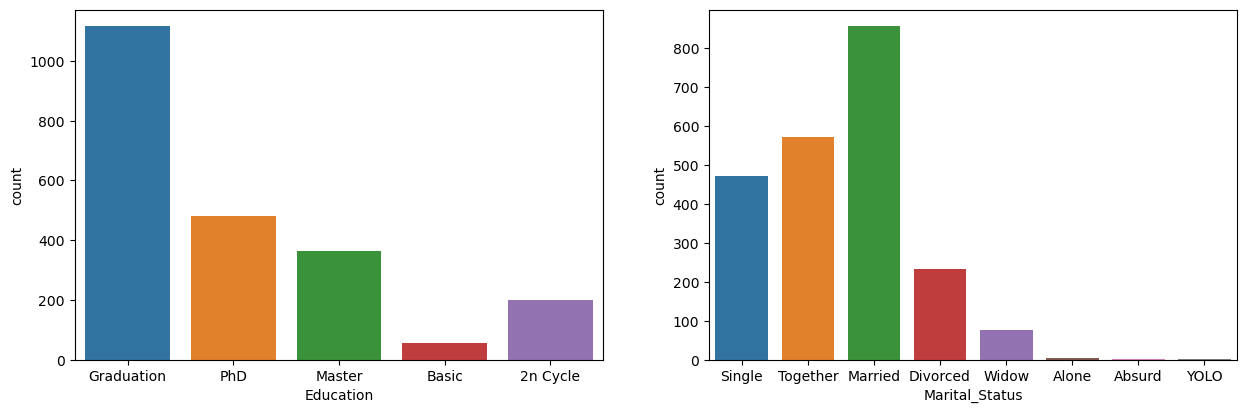

In [17]:
plt.subplots(figsize=(15,10))
for i, col in enumerate(objects):
    plt.subplot(2,2,i+1)
    sb.countplot(df[col])
plt.show()

In [18]:
df['Marital_Status'].value_counts()

Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: Marital_Status, dtype: int64

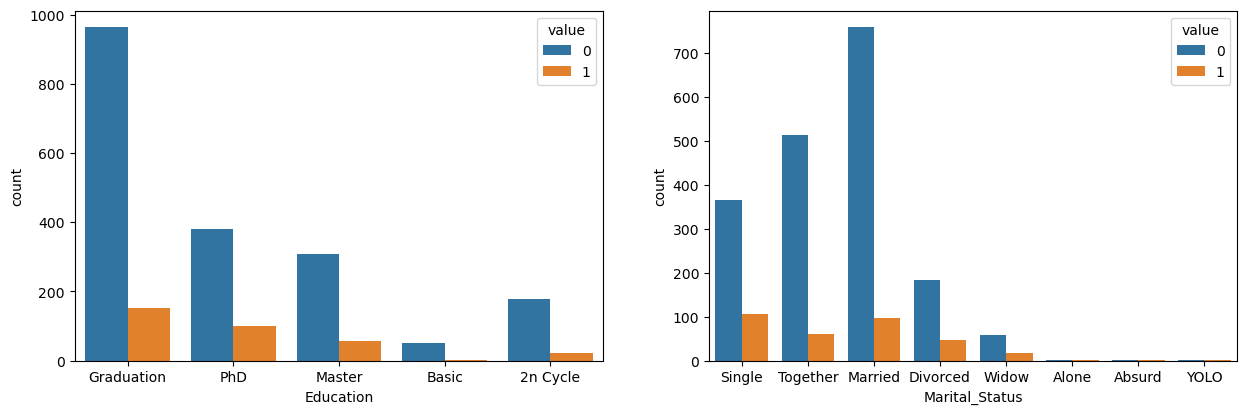

In [21]:
plt.subplots(figsize=(15,10))
for i, col in enumerate(objects):
    plt.subplot(2,2,i+1)
    df_melted = df.melt(id_vars=[col],value_vars=['Response'],var_name='hue')
    sb.countplot(x=col, hue='value',data=df_melted)
plt.show()

In [22]:
#Label Encoding

for col in df.columns:
    if df[col].dtype == object:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])

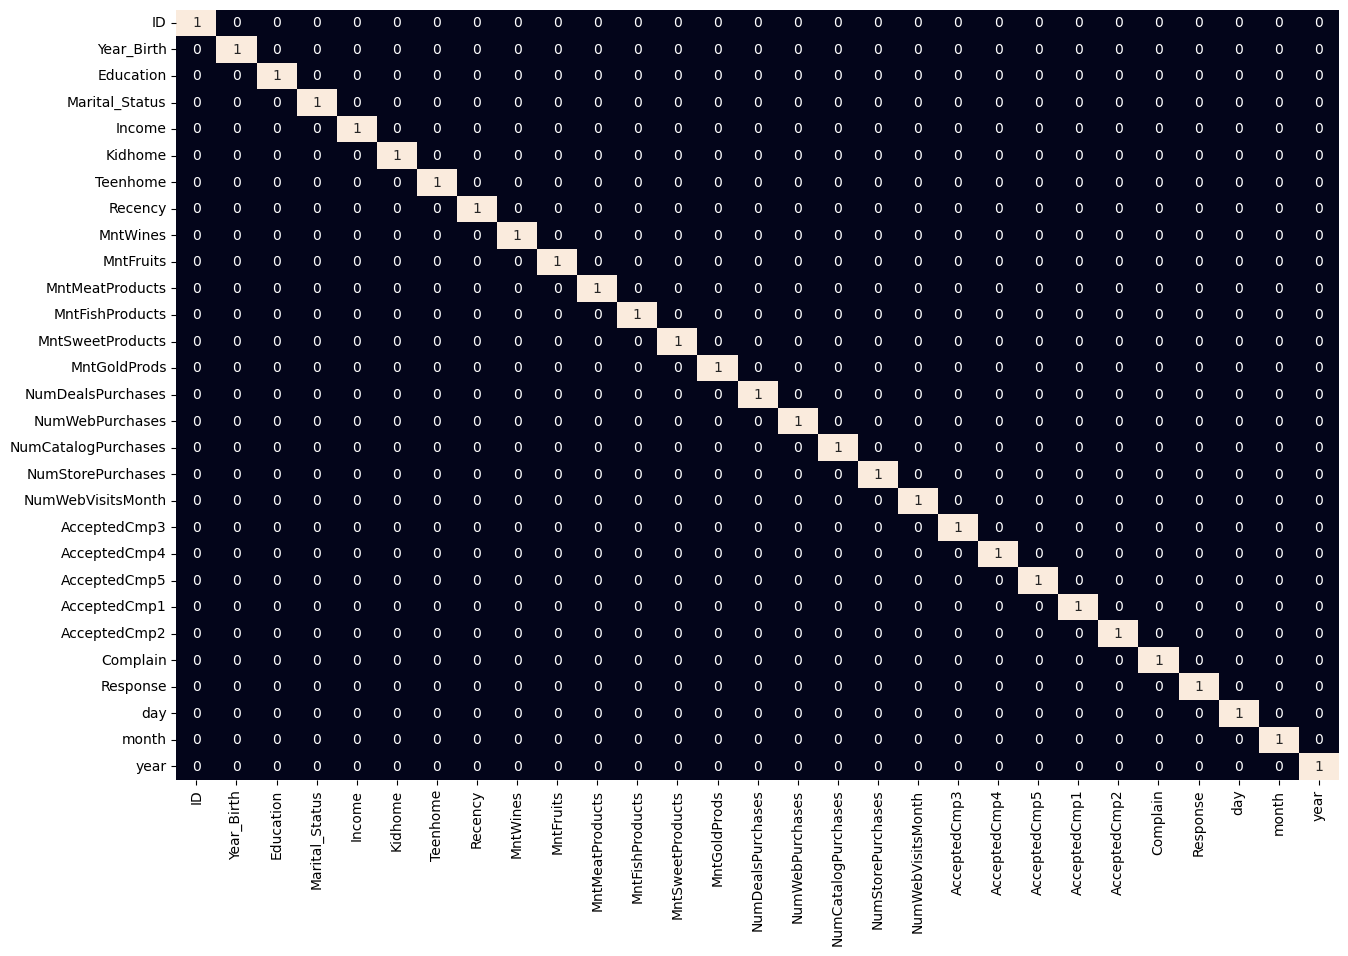

In [23]:
plt.figure(figsize=(15,10))
sb.heatmap(df.corr()>0.8, annot = True, cbar = False)
plt.show()

In [24]:
#Standardization

scaler = StandardScaler()
data = scaler.fit_transform(df)

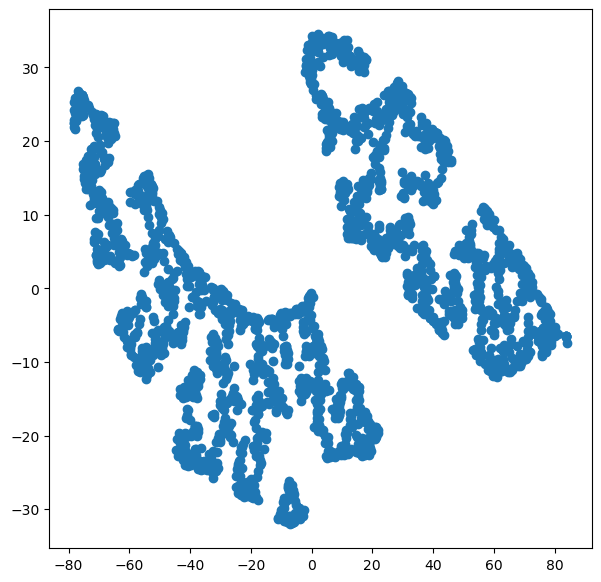

In [26]:
#T-distributed Stochastic Neighbour Embedding
from sklearn.manifold import TSNE
model = TSNE(n_components = 2, random_state = 42)
tsne_data = model.fit_transform(df)
plt.figure(figsize=(7,7))
plt.scatter(tsne_data[:,0], tsne_data[:,1])
plt.show()

In [27]:
error = []
for n_clusters in range(1, 21):
    model = KMeans(init='k-means++',
                   n_clusters=n_clusters,
                   max_iter=500,
                   random_state=22)
    model.fit(df)
    error.append(model.inertia_)

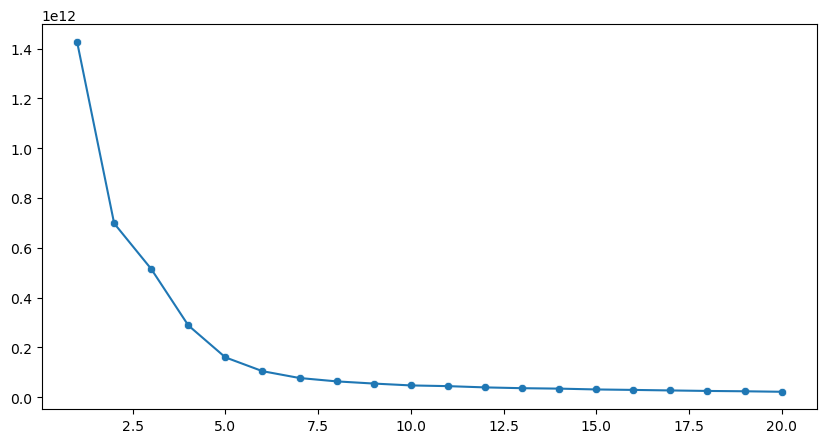

In [28]:
plt.figure(figsize=(10, 5))
sb.lineplot(x=range(1, 21), y=error)
sb.scatterplot(x=range(1, 21), y=error)
plt.show()

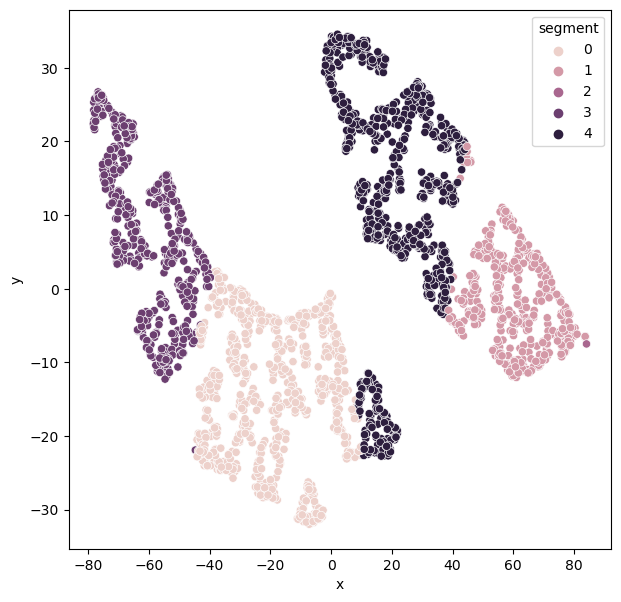

In [30]:
# k woud be 6

model = KMeans(init = 'k-means++',
              n_clusters = 5, max_iter = 500, random_state = 41)
segments = model.fit_predict(df)

plt.figure(figsize = (7,7))
df_tsne = pd.DataFrame({"x": tsne_data[:,0],"y": tsne_data[:,1], 'segment':segments})

sb.scatterplot(x='x', y='y', hue = "segment", data = df_tsne)
plt.show()